In [1]:
import numpy as np
import skimage
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


seed = 42
np.random.seed(seed)


def plot_steps(steps, title, step_numbers=None):
    step_numbers = step_numbers or list(range(1, len(steps) + 1))

    plt.figure()
    plt.plot(step_numbers, steps, marker='o')
    plt.title(title)
    plt.grid(True)
    plt.show()


def rank_k_approx(U, sigmas, V, k):
    m = U.shape[0]
    n = V.shape[0]
    A_k = np.zeros((m, n))
    assert 1 <= k <= min(m, n)

    for i in range(k):
        sigma_i = sigmas[i]
        u_i = U[:, i]
        v_i = V[i, :]  # i-th row of V^T = i-th right singular vector
        A_k += sigma_i * np.outer(u_i, v_i)

    return A_k

# Exercise 1

In [2]:
A = np.matlib.rand(10,6)
U, sigmas, V = np.linalg.svd(A)
S = np.zeros(A.shape)
np.fill_diagonal(S, sigmas)
print(f"shape(U)={U.shape}")
print(f"shape(S)={S.shape}")
print(f"shape(V)={V.shape}")
error = np.linalg.norm(A - (U @ S @ V), ord='fro')

print(f"Matrix approximation error: {error}")

for i in range(min(A.shape)):
    print(f"sigma_{i}: {S[i,i]}")

shape(U)=(10, 10)
shape(S)=(10, 6)
shape(V)=(6, 6)
Matrix approximation error: 5.753235449447704e-15
sigma_0: 3.7560266487866087
sigma_1: 1.4242415185172967
sigma_2: 1.047823997698587
sigma_3: 0.8847132945788712
sigma_4: 0.7197798688154057
sigma_5: 0.28714759044046934


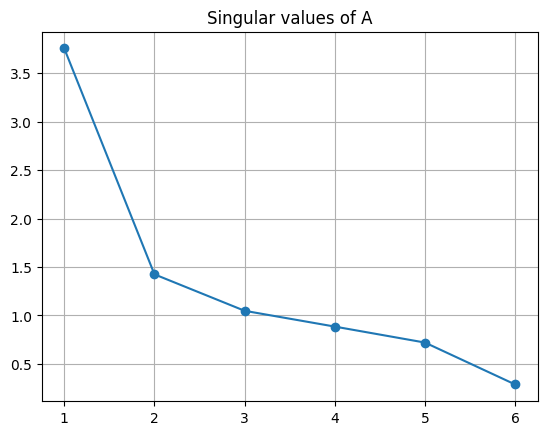

In [3]:
plot_steps(sigmas, "Singular values of A")

SVD returns singular values in descending order because they represent stretch factors along orthogonal directions and the algorithm naturally puts the most energetic direction first. Small $\sigma_i$ matter little because dropping rank-$i$ adds only $\sigma_i^2$ to the squared Frobenius error, so tiny values contribute negligibly to the reconstruction. The $\sim 10^{-15}$ residual isn't zero because floating-point arithmetic can't represent exact linear dependence

# Exercise 2

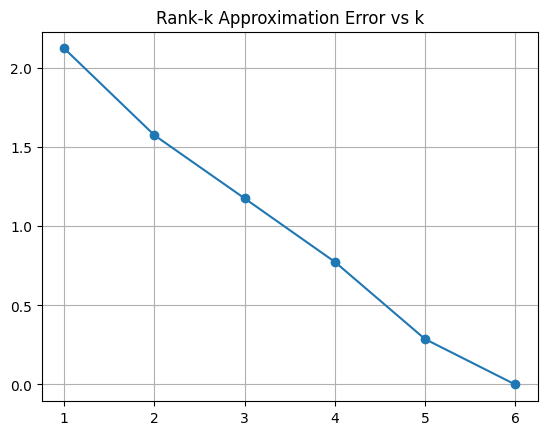

In [4]:

errors = []

for k in range(min(A.shape)):
    A_k = rank_k_approx(U, sigmas, V, k + 1)
    errors.append(np.linalg.norm(A - A_k, ord='fro'))

plot_steps(errors, 'Rank-k Approximation Error vs k')

By the Eckart-Young theorem, $A_k = \sum_{i=1}^k \sigma_i u_i v_i^T$ minimises $\|A - B\|_F$ over all rank-$k$ matrices $B$.  We can see this in the plot: error drops monotonically and reaches zero once $k$ equals the rank of $A$. No other rank-$k$ approximation can do better.

# Exercise 3

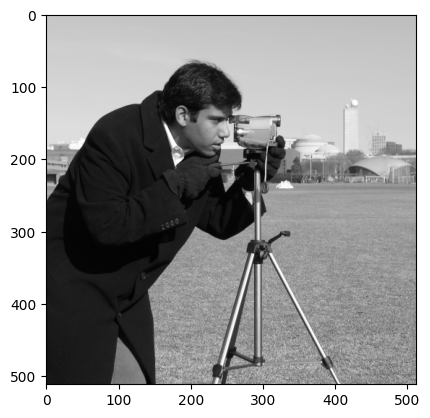

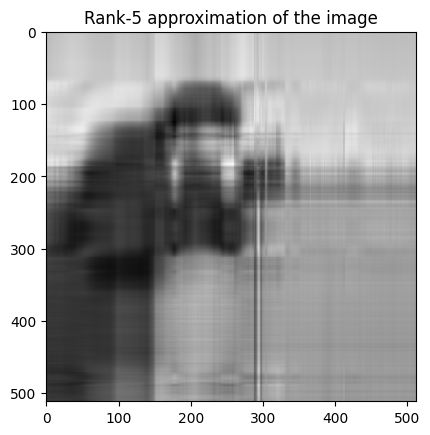

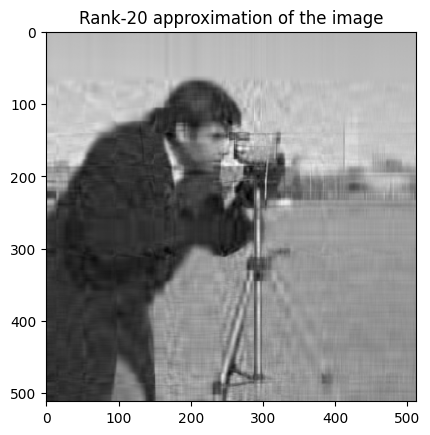

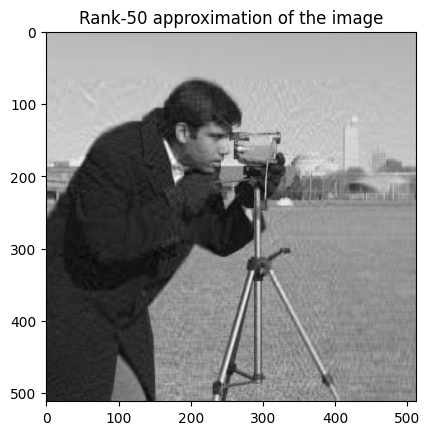

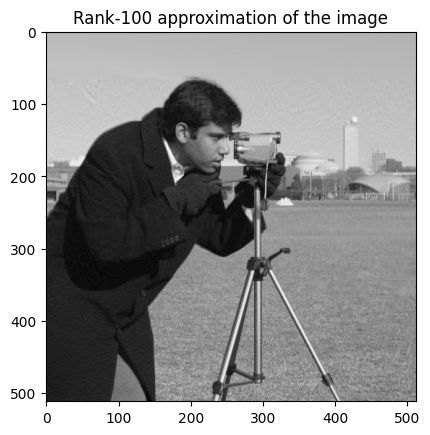

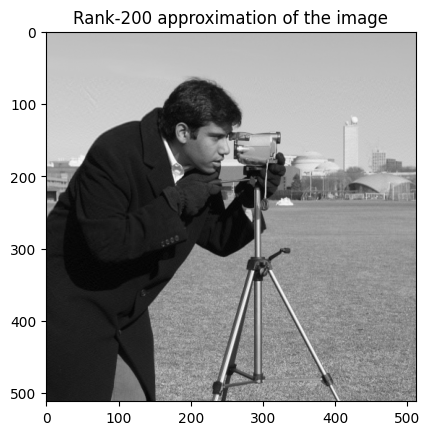

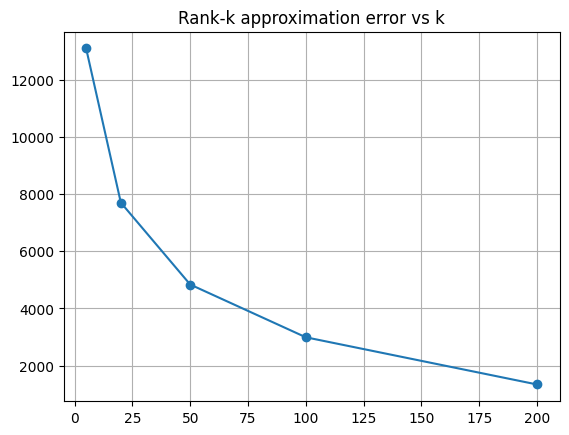

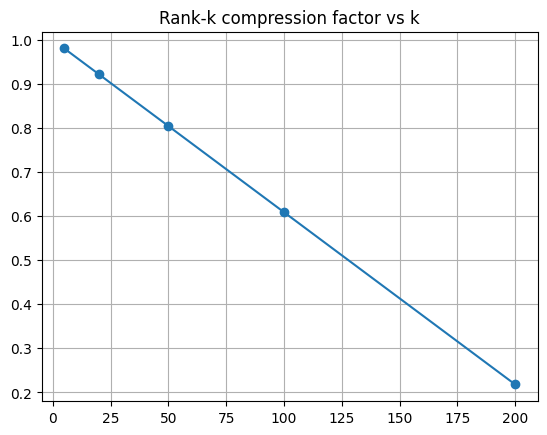

In [5]:
X = skimage.data.camera()
m, n = X.shape
U, sigmas, V = np.linalg.svd(X)
plt.imshow(X, cmap="gray")
plt.show()

errors = []
compressions = []
ranks = [5, 20, 50, 100, 200]

for k in ranks:
    X_k = rank_k_approx(U, sigmas, V, k)
    errors.append(np.linalg.norm(X - X_k, ord='fro'))
    compressions.append(1 - (k * (m + n + 1)) / (m * n))
    
    plt.imshow(X_k, cmap="gray")
    plt.title(f"Rank-{k} approximation of the image")
    plt.show()

plot_steps(errors, 'Rank-k approximation error vs k', step_numbers=ranks)
plot_steps(compressions, 'Rank-k compression factor vs k', step_numbers=ranks)

At low $k$ the image is blurry because only coarse, global structure is captured and details are recovered as $k$ grows. This works well because natural images tend to have rapidly decaying singular values, so the error curve drops steeply then flattens. Since SVD gives the best possible rank-$k$ linear approximation (Eckart–Young), no other method can achieve lower reconstruction error at the same storage cost. This can introduce a trade-off between the compression and fidelity as as low rank approximations only need to store a few vectors from the singular vector matrices and a few singular values, instead of the full 512x512 matrix

# Exercise 5

In [6]:
data = np.genfromtxt("assets/train.csv", delimiter=",")[1:]
images = data[:,1:]
labels = data[:,0]
print(f"Shape of images: {images.shape}")
print(f"Labels {np.unique(labels)}")


Shape of images: (42000, 784)
Labels [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [7]:
def filter_and_split(labels_to_filter):
    """Given the list of labels to keep in the dataset, returns a train/test split of global `images`
    and `labels` for only those classes"""

    mask = np.isin(labels, labels_to_filter)
    filtered_images = images[mask]
    filtered_labels = labels[mask]
    print(f"Got {filtered_images.shape[0]} images for digits {labels_to_filter}")
    xtrain, xtest, ytrain, ytest = train_test_split(
        filtered_images, filtered_labels, test_size=0.2, random_state=seed
    )
    print(f"Keeping {xtrain.shape[0]} images for training")
    return xtrain, xtest, ytrain, ytest


def center_and_factorize(x):
    """Centers the data `x` and returns the centroid and the SVD decomposition of `x` centered"""

    centroid = np.mean(x, axis=0)
    centered = x - centroid.reshape((1, len(centroid)))
    U, s, VT = np.linalg.svd(centered, full_matrices=False)
    return centered, U, s, VT


def pca_k2(labels_to_filter):
    """Given the labesl to focus on, centers data, performs SVD, projects train and test data,
    and plots the obtained clusters"""

    xtrain, xtest, ytrain, ytest = filter_and_split(labels_to_filter)
    centroid = xtrain.mean(axis=0)
    centered, _, _, VT = center_and_factorize(xtrain)
    P = VT[:2]
    ztrain = centered @ P.T
    ztest  = (xtest - centroid) @ P.T

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, z, y, split in zip(axes, [ztrain, ztest], [ytrain, ytest], ["Train", "Test"]):
        sc = ax.scatter(z[:, 0], z[:, 1], c=y, s=5, alpha=0.4)
        ax.legend(*sc.legend_elements(), title="Digit")
        ax.set(xlabel="$z_1$", ylabel="$z_2$", title=f"PCA k=2 — {split} {labels_to_filter}")
        ax.grid()
    plt.tight_layout()
    plt.show()

Got 8423 images for digits [3, 4]
Keeping 6738 images for training


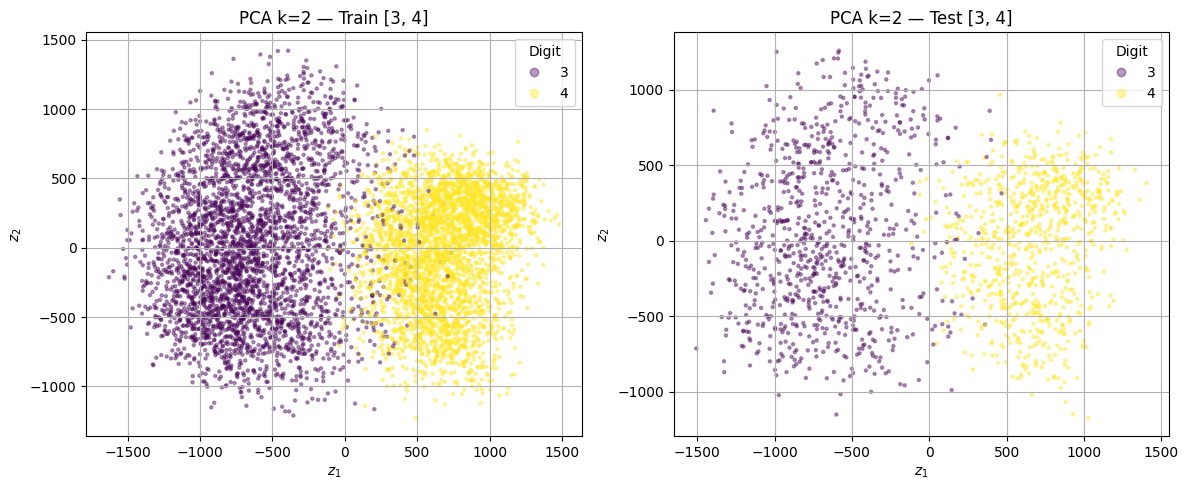

In [8]:
pca_k2([3,4])

Got 7858 images for digits [5, 8]
Keeping 6286 images for training


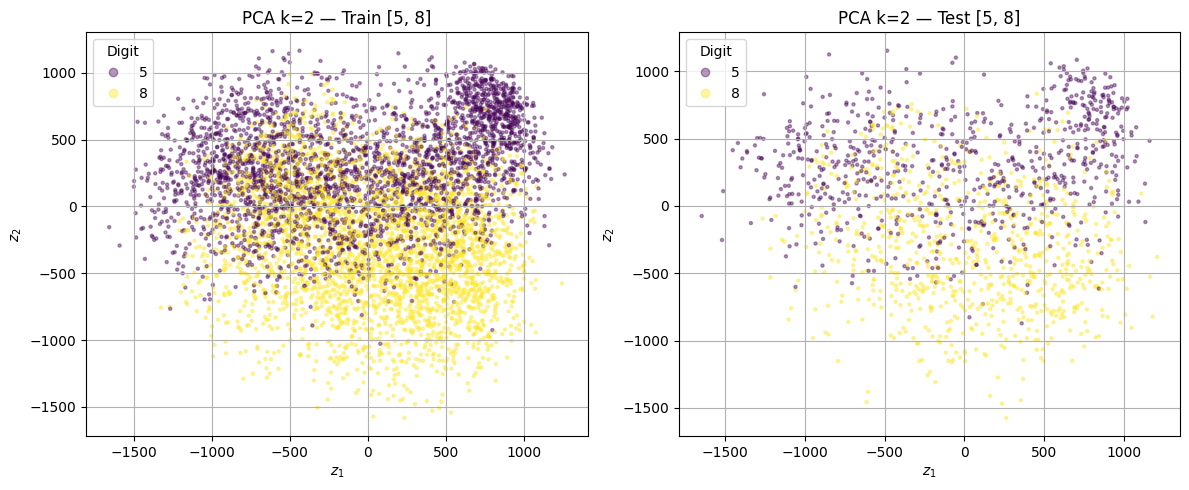

In [9]:
pca_k2([5,8])


Got 9085 images for digits [1, 7]
Keeping 7268 images for training


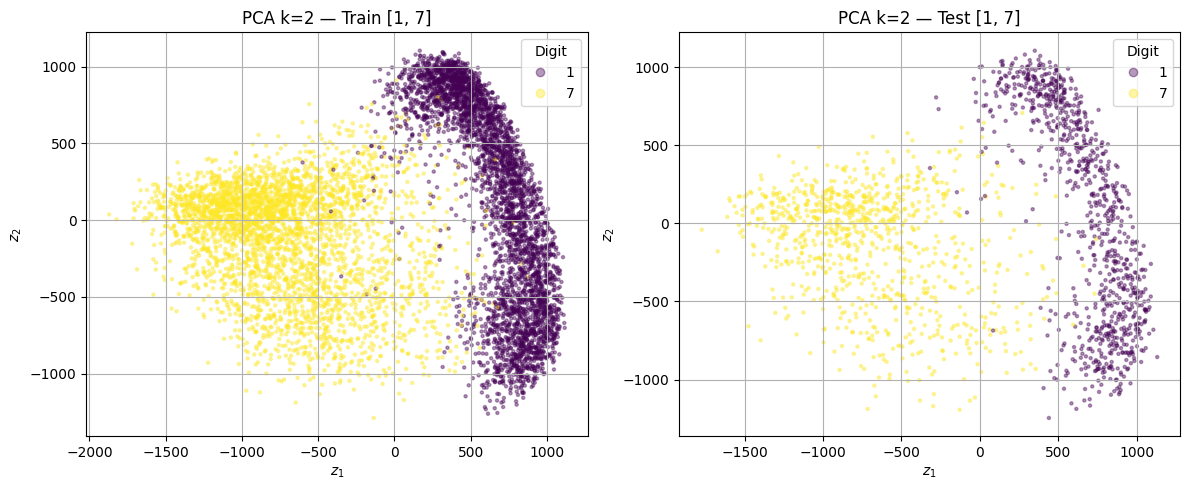

In [10]:
pca_k2([1,7])

Got 8423 images for digits [3, 4]
Keeping 6738 images for training
Shape of projected data: (6738, 3)


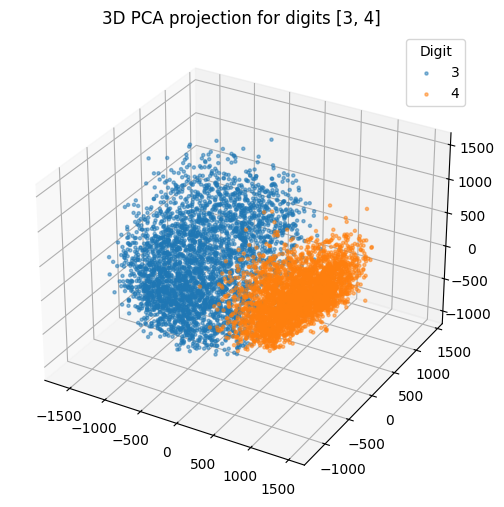

In [11]:
labels_to_filter = [3,4]
xtrain, xtest, ytrain, ytest = filter_and_split(labels_to_filter)
centered, U, s, VT = center_and_factorize(xtrain)
P = VT[:3]
ztrain = centered @ P.T
print(f"Shape of projected data: {ztrain.shape}")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for label in labels_to_filter:
    m = ytrain == label
    ax.scatter(ztrain[m, 0], ztrain[m, 1], ztrain[m, 2], label=str(int(label)), s=5, alpha=0.5)
ax.set_title(f'3D PCA projection for digits {labels_to_filter}')
ax.legend(title='Digit')
plt.show()

Visually dissimilar pairs like 1/7 form tight, well-separated clusters in the 2D PCA projection; more similar pairs like 5/8 overlap more, since PCA maximises variance rather than class separation. Test projections closely mirror the training clusters, confirming the top components generalise well. Adding a third component captures some extra variance but the gain is modest when singular values fall off quickly after the first two.

# Exercise 6

In [12]:
def performance(gt, predictions):
    # derive labels from data so the function works for any digit pair
    labels = sorted(int(l) for l in np.unique(np.concatenate([gt, predictions])))
    print(f"Accuracy:  {accuracy_score(gt, predictions):.4f}")
    print(f"Precision: {precision_score(gt, predictions, pos_label=labels[0]):.4f}")
    print(f"Recall:    {recall_score(gt, predictions, pos_label=labels[0]):.4f}")
    ConfusionMatrixDisplay(confusion_matrix(gt, predictions), display_labels=labels).plot()
    plt.title(f'Confusion Matrix — digits {labels}')
    plt.show()


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


def sigmoid_grad(Z, y, theta):
    return Z.T @ (sigmoid(Z @ theta) - y) / len(y)


In [13]:
# SGD hyperparameters shared by linear_classifier
lr = 0.000001
n_epochs = 50
batch_size = 64


def linear_classifier(digits):
    """Trains logistic regression on PCA features"""

    d0, d1 = digits
    xtrain, xtest, ytrain, ytest = filter_and_split(digits)

    # project training and test sets onto top-2 PCA directions
    centroid = xtrain.mean(axis=0)
    centered, _, _, VT = center_and_factorize(xtrain)
    P = VT[:2]
    ztrain = centered @ P.T
    ztest  = (xtest - centroid) @ P.T

    # d0 → 0, d1 → 1
    ytrain_b = (ytrain == d1).astype(float)
    # add bias column
    Ztrain = np.hstack([ztrain, np.ones((len(ztrain), 1))])
    Ztest  = np.hstack([ztest,  np.ones((len(ztest),  1))])

    theta = np.zeros(3)
    loss_history = []

    for epoch in range(n_epochs):
        perm = np.random.permutation(len(Ztrain))
        epoch_loss, n_batches = 0.0, 0
        for start in range(0, len(Ztrain), batch_size):
            b = perm[start:start + batch_size]
            z_b, y_b = Ztrain[b], ytrain_b[b]
            p = sigmoid(z_b @ theta)
            theta -= lr * sigmoid_grad(z_b, y_b, theta)
            epoch_loss += -np.mean(y_b * np.log(p + 1e-12) + (1 - y_b) * np.log(1 - p + 1e-12))
            n_batches += 1
        loss_history.append(epoch_loss / n_batches)

    plot_steps(loss_history, f'Training loss — digits {digits}')

    # decision boundary: theta·[z1, z2, 1]^T = 0  →  z2 = -(theta[0]*z1 + theta[2]) / theta[1]
    z1_range = np.linspace(ztrain[:, 0].min(), ztrain[:, 0].max(), 300)
    z2_boundary = -(theta[0] * z1_range + theta[2]) / theta[1]

    plt.figure(figsize=(8, 6))
    for label in digits:
        m = ytrain == label
        plt.scatter(ztrain[m, 0], ztrain[m, 1], s=5, alpha=0.4, label=str(int(label)))
    plt.plot(z1_range, z2_boundary, 'k-', linewidth=2, label='Decision boundary')
    plt.xlabel('$z_1$'); plt.ylabel('$z_2$')
    plt.title(f'PCA + LR boundary (train) — digits {digits}')
    plt.legend(title='Digit'); plt.grid()
    plt.show()

    pred = np.where(sigmoid(Ztest @ theta) >= 0.5, d1, d0)
    performance(ytest, pred)

    return dict(z1_range=z1_range, z2_boundary=z2_boundary)


def pca_classifier(digits, lr_state=None):
    """Classifies test samples by nearest centroid in PCA space.

    If lr_state is the dict returned by linear_classifier, the LR decision
    boundary is overlaid on the misclassification scatter plot.
    """
    d0, d1 = digits
    xtrain, xtest, ytrain, ytest = filter_and_split(digits)

    centroid = xtrain.mean(axis=0)
    centered, _, _, VT = center_and_factorize(xtrain)
    P = VT[:2]
    ztrain = centered @ P.T
    ztest  = (xtest - centroid) @ P.T

    # per-class centroids in PCA space
    mu = {d: ztrain[ytrain == d].mean(axis=0) for d in digits}
    # classify each test point to the nearest centroid
    pred = np.array([min(digits, key=lambda d: np.linalg.norm(z - mu[d])) for z in ztest])
    performance(ytest, pred)

    # scatter: correctly classified by class, misclassified in red
    wrong = pred != ytest
    plt.figure(figsize=(8, 6))
    for d in digits:
        m = (ytest == d) & ~wrong
        plt.scatter(ztest[m, 0], ztest[m, 1], s=8, alpha=0.4, label=str(int(d)))
    plt.scatter(ztest[wrong, 0], ztest[wrong, 1], s=15, c='red', marker='x', label='misclassified')
    for d in digits:
        plt.scatter(*mu[d], marker='*', s=200, edgecolors='k', zorder=5, label=f'centroid {int(d)}')
    if lr_state is not None:
        plt.plot(lr_state['z1_range'], lr_state['z2_boundary'], 'k-', lw=2, label='LR boundary')
    plt.xlabel('$z_1$'); plt.ylabel('$z_2$')
    plt.title(f'Centroids + misclassified — digits {digits}')
    plt.legend(fontsize=7); plt.grid()
    plt.show()


Got 8423 images for digits [3, 4]
Keeping 6738 images for training


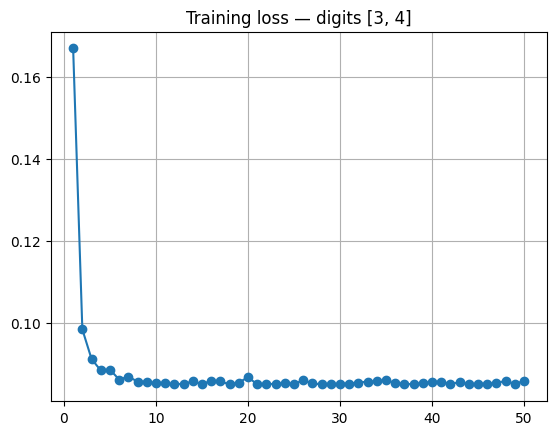

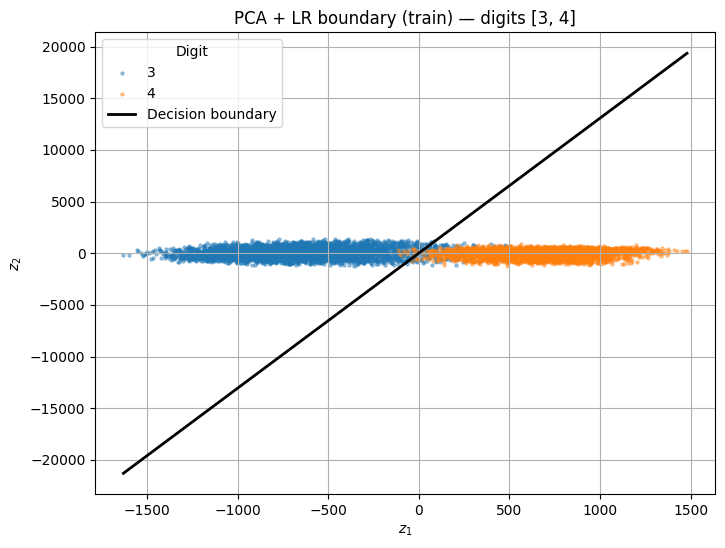

Accuracy:  0.9715
Precision: 0.9928
Recall:    0.9519


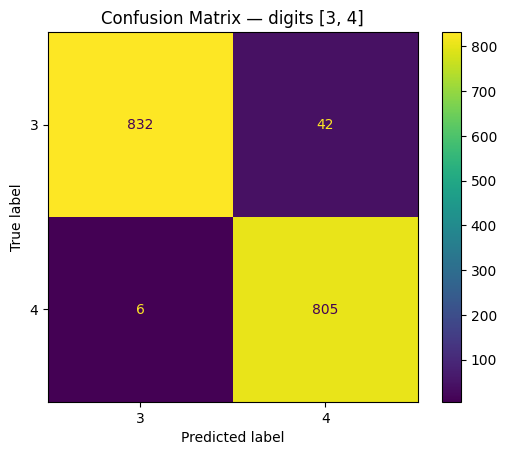

In [14]:
lr_state = linear_classifier([3, 4])

Got 8423 images for digits [3, 4]
Keeping 6738 images for training
Accuracy:  0.9721
Precision: 0.9917
Recall:    0.9542


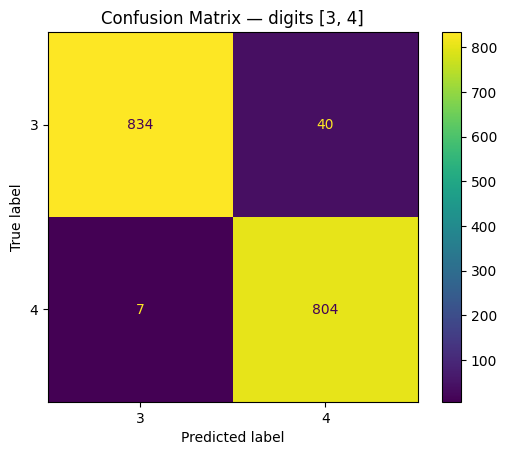

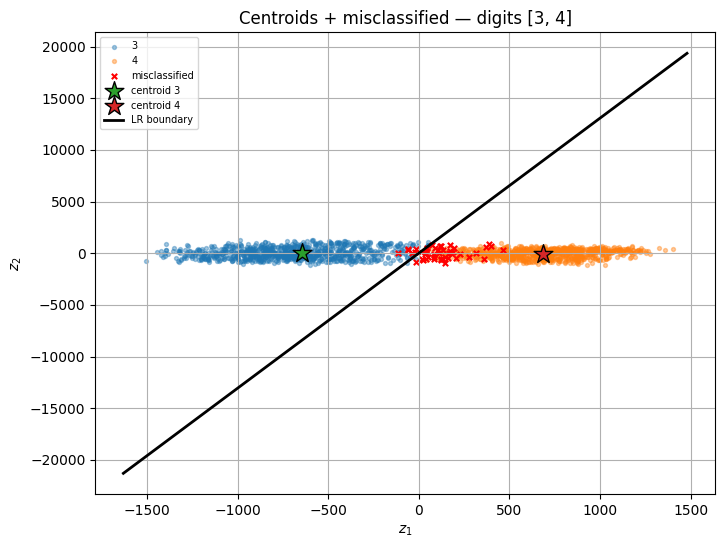

In [15]:
pca_classifier([3, 4], lr_state)

Got 9085 images for digits [1, 7]
Keeping 7268 images for training


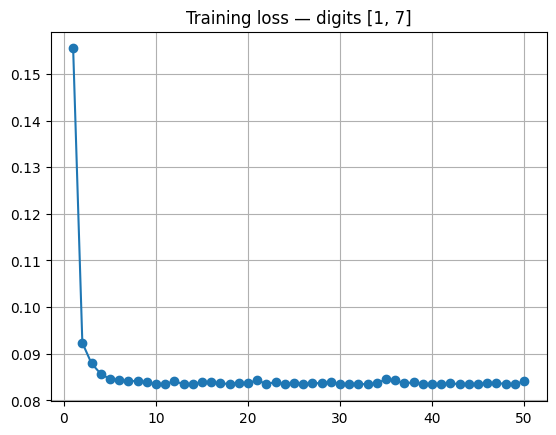

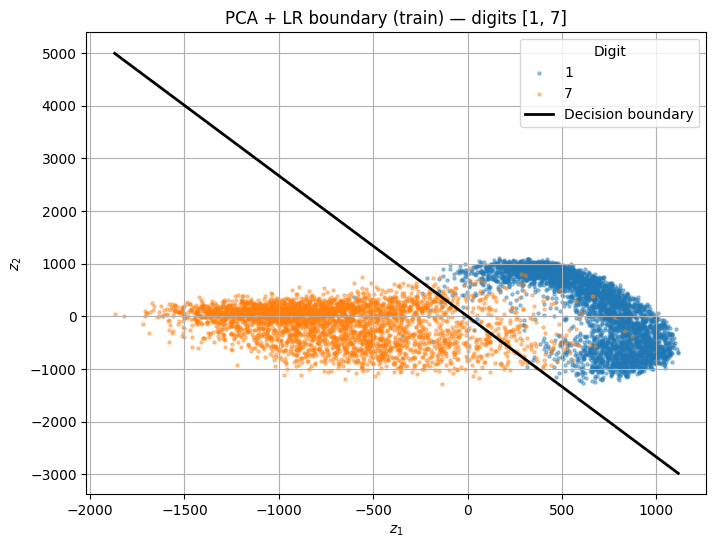

Accuracy:  0.9670
Precision: 0.9415
Recall:    0.9944


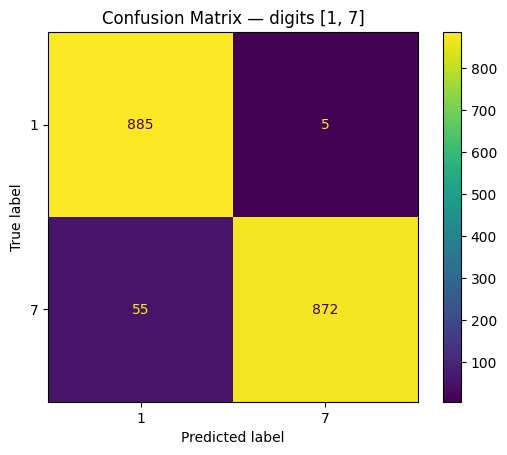

Got 9085 images for digits [1, 7]
Keeping 7268 images for training
Accuracy:  0.9554
Precision: 0.9218
Recall:    0.9933


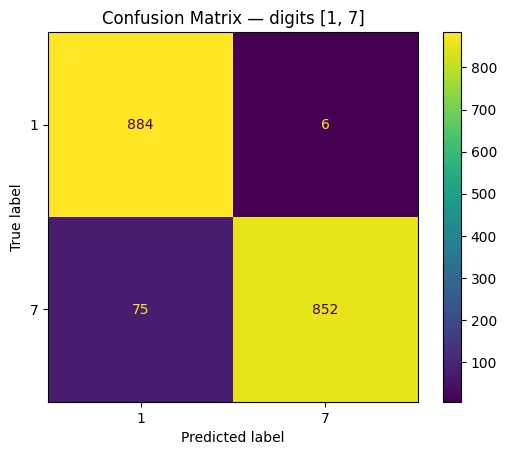

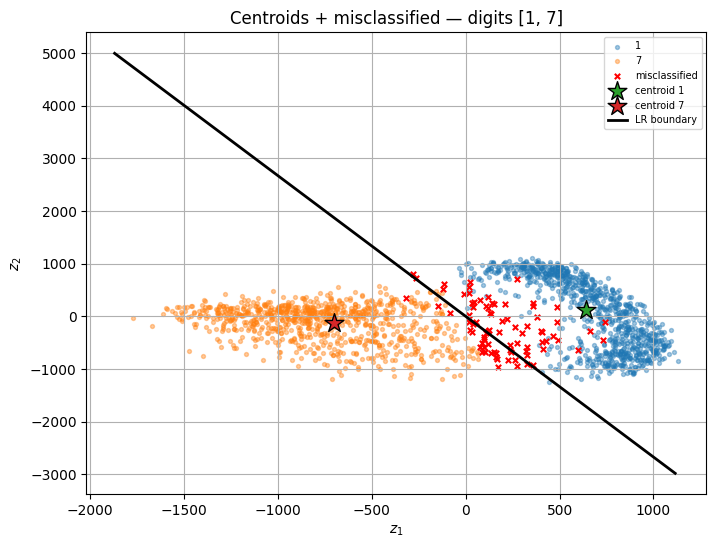

In [16]:
lr_state = linear_classifier([1, 7])
pca_classifier([1, 7], lr_state)

Got 7858 images for digits [5, 8]
Keeping 6286 images for training


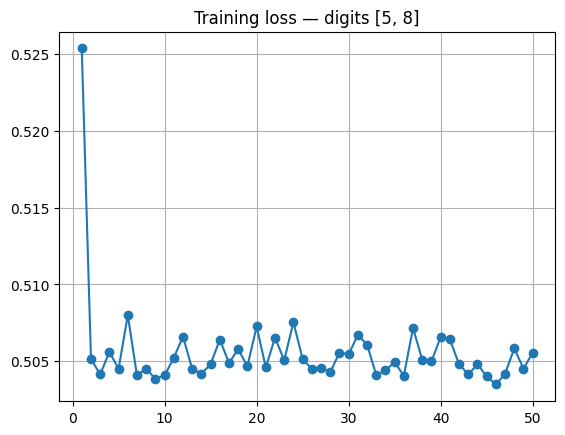

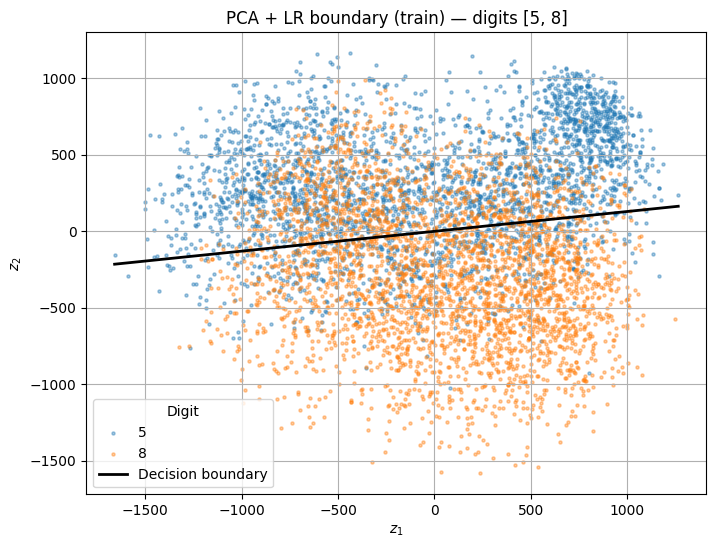

Accuracy:  0.7691
Precision: 0.7423
Recall:    0.7944


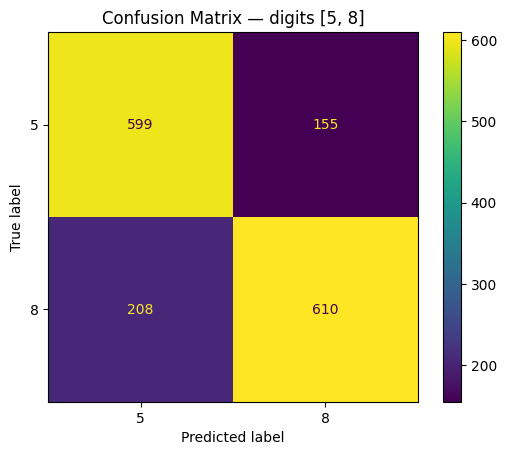

Got 7858 images for digits [5, 8]
Keeping 6286 images for training
Accuracy:  0.7678
Precision: 0.7434
Recall:    0.7878


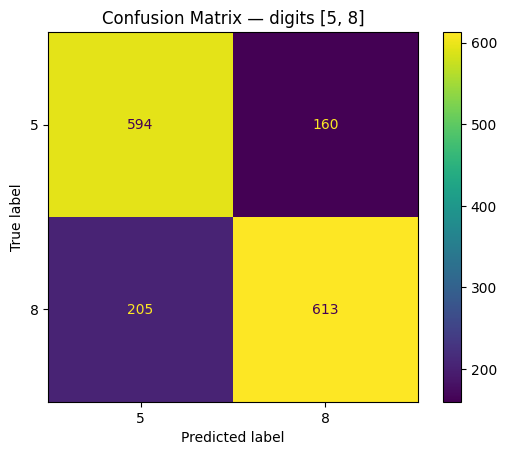

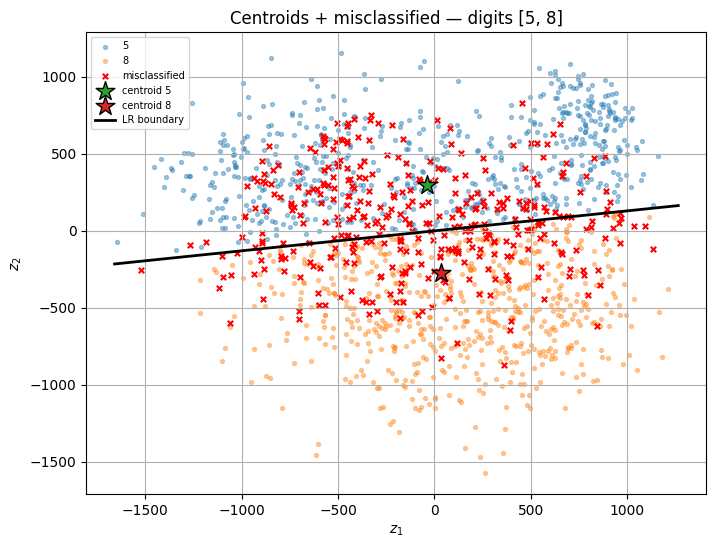

In [17]:
lr_state = linear_classifier([5, 8])
pca_classifier([5, 8], lr_state)

Got 8528 images for digits [2, 3]
Keeping 6822 images for training


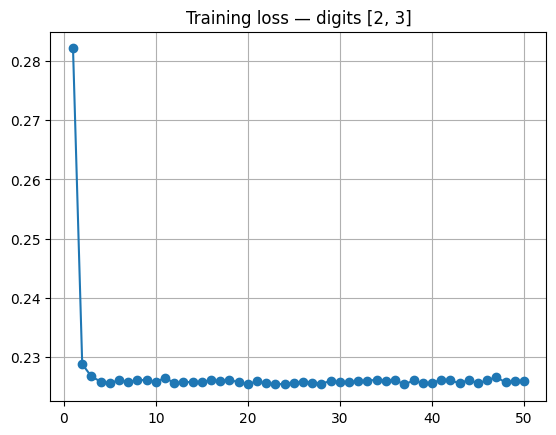

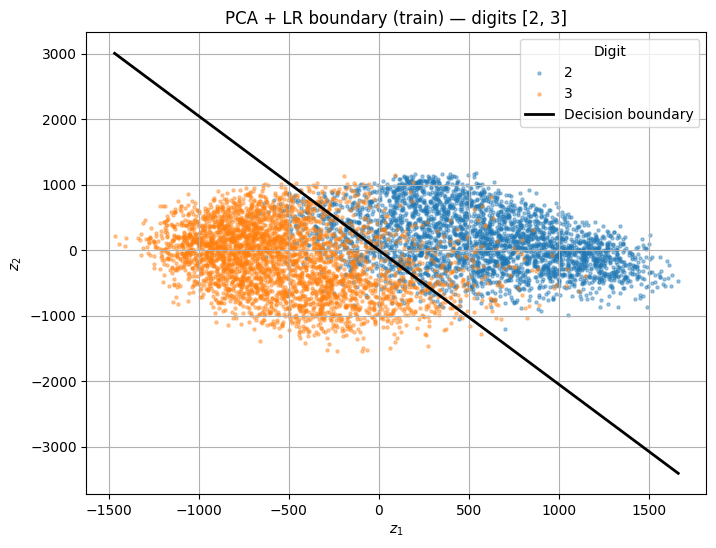

Accuracy:  0.9150
Precision: 0.9141
Recall:    0.9108


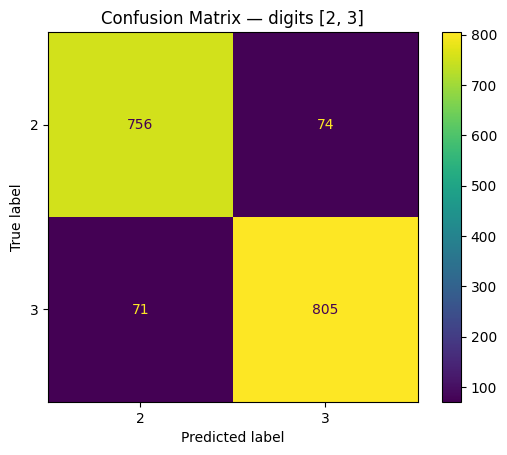

Got 8528 images for digits [2, 3]
Keeping 6822 images for training
Accuracy:  0.9039
Precision: 0.9101
Recall:    0.8904


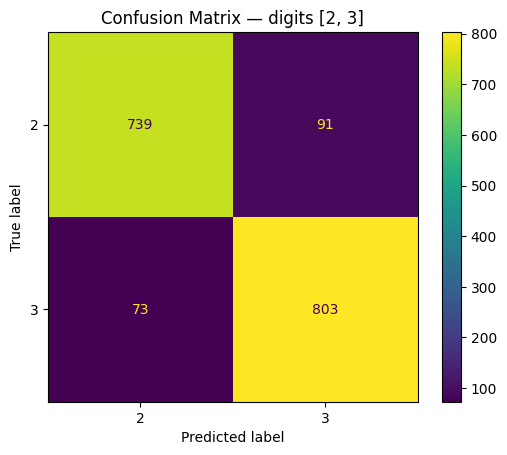

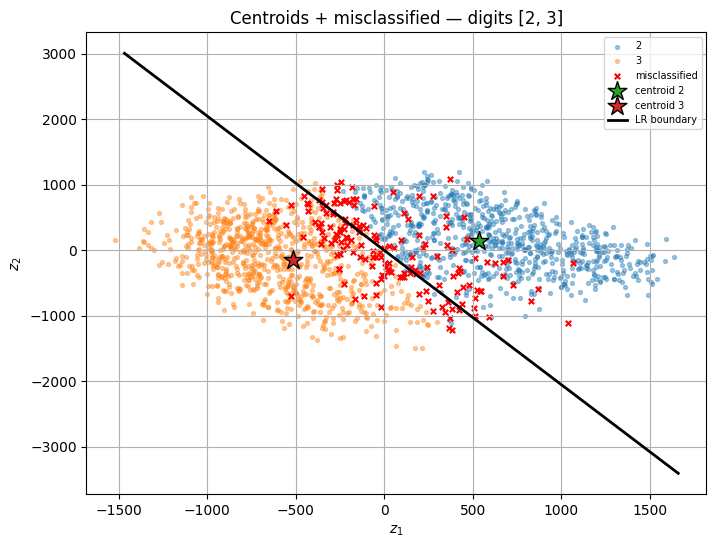

In [18]:
lr_state = linear_classifier([2, 3])
pca_classifier([2, 3], lr_state)

When classes have similar spread the centroid classifier's boundary (perpendicular bisector of the means) nearly coincides with logistic regression's, so accuracy is close (although the PCA clalssifier is consistently slightly less performant). Logistic regression has an edge when covariances differ because it fits the boundary directly rather than relying on centroids. Harder pairs like 5/8 and 2/3 produce more overlapping PCA clusters — both classifiers struggle there, and misclassified samples cluster near the boundary where the two digit shapes are most ambiguous. Dissimilar pairs like 1/7 give well-separated clusters and near-perfect accuracy for both methods.